In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import chi2

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent.parent

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from configs.datasets.real import SCM20dDatasetConfig
from configs.predictors.rearranged_transport import (
    AmortizedRearrangedTransportPredictorConfig,
)
from configs.predictors.transport import (
    NeuralOptimalTransportPredictorConfig
)
from configs.trainers.rearranged_transport import (
    AmortizedRearrangedTransportTrainerConfig
)
from configs.trainers.transport import (
    NeuralOptimalTransportTrainerConfig
)
from data.datasets.real import SCM20dDataset
from data.loaders import make_xy_dataloader
from predictors.rearranged_transport import AmortizedRearrangedTransport
from predictors.transport import NeuralOptimalTransportPredictor
from trainers.rearranged_transport import AmortizedRearrangedTransportTrainer
from trainers.transport import NeuralOptimalTransportTrainer

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [3]:
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

device = "cpu"
dtype = "float32"

batch_size = 1024

In [7]:
dataset_config = SCM20dDatasetConfig(
    seed=seed,
    device=device,
    dtype=dtype,
)

dataset = SCM20dDataset(dataset_config)
splits = dataset.get_splits()

train_dataloader = make_xy_dataloader(
    data=splits.train,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

print("train x/y:", splits.train.x.shape, splits.train.y.shape)
print("calibration x/y:", splits.calibration.x.shape, splits.calibration.y.shape)
print("test x/y:", splits.test.x.shape, splits.test.y.shape)

train x/y: torch.Size([5379, 61]) torch.Size([5379, 16])
calibration x/y: torch.Size([1793, 61]) torch.Size([1793, 16])
test x/y: torch.Size([1794, 61]) torch.Size([1794, 16])


In [17]:
predictor_config = NeuralOptimalTransportPredictorConfig(
    x_dim=dataset.x_dim,
    y_dim=dataset.y_dim,
    hidden_dim=32,
    num_hidden_layers=8,
    c_transform_lr=1.,
    c_transform_max_iter=1000,
    seed=seed,
    device=device,
    dtype=dtype,
)

trainer_config = NeuralOptimalTransportTrainerConfig(
    epochs=250,
    learning_rate=1e-3,
    weight_decay=1e-4,
    warmup_iterations=50,
    grad_clip_norm=20.0,
    use_cosine_scheduler=True,
    verbose=True,
)

predictor = NeuralOptimalTransportPredictor(predictor_config)
trainer = NeuralOptimalTransportTrainer(trainer_config)

# predictor = predictor.load("../../weights/neural_ot_predictor.pt")

predictor = trainer.fit(
    predictor=predictor,
    dataloader=train_dataloader,
)
predictor.eval()

trainer.training_history[-5:]

Warming Neural Quantile:   0%|          | 0/50 [00:00<?, ?it/s]

Warmup 50 | Loss 0.2377: 100%|██████████| 50/50 [00:03<00:00, 14.23it/s]
Epoch 250 | Potential loss 6.5932: 100%|██████████| 250/250 [06:21<00:00,  1.53s/it]


[{'epoch': 246,
  'potential_loss': 6.6316633224487305,
  'epoch_time': 1.130257791999611,
  'learning_rate': 6.315216969912637e-07},
 {'epoch': 247,
  'potential_loss': 6.745436191558838,
  'epoch_time': 1.1359414590115193,
  'learning_rate': 3.552636797053962e-07},
 {'epoch': 248,
  'potential_loss': 6.6031951904296875,
  'epoch_time': 1.1252755419991445,
  'learning_rate': 1.5790535835002944e-07},
 {'epoch': 249,
  'potential_loss': 6.727084159851074,
  'epoch_time': 1.2196769579895772,
  'learning_rate': 3.947789809194398e-08},
 {'epoch': 250,
  'potential_loss': 6.593234062194824,
  'epoch_time': 1.240641875003348,
  'learning_rate': 0.0}]

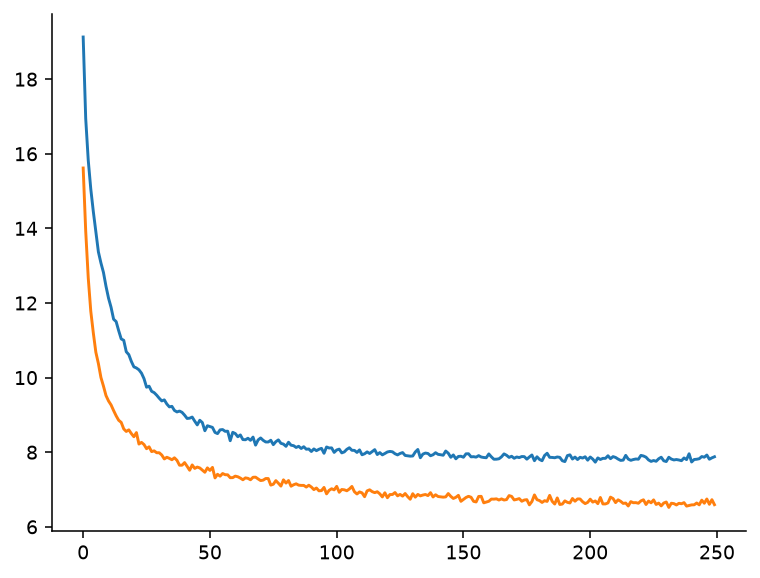

In [18]:
plt.plot([epoch['potential_loss'] for epoch in trainer_history_5_3])
plt.plot([epoch['potential_loss'] for epoch in trainer.training_history])
plt.show()